# Brachistochrone GKP Logical Gates

This notebook constructs the time-optimal (quantum brachistochrone) Hamiltonian implementing logical single-qubit gates on a finite-energy GKP code, following Carlini et al., *Phys. Rev. Lett.* **96**, 060503 (2006). Each gate is specified by a pair of cardinal GKP states $\ket{\psi_i} \to \ket{\psi_f}$ on the logical Bloch sphere; the construction returns the constant $H$ that drives the transition in the minimum time $T = \Omega_B / \lVert H \rVert$ allowed by the Mandelstam-Tamm bound. The resulting Hamiltonians are benchmarks — lower bounds on gate time at fixed energy budget — against which realistic control schemes can be compared.


## Imports


In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from gkp_optimal_control.animation import animate_wigner
from gkp_optimal_control.brachistochrone import quantum_brachistochrone_hamiltonian
from gkp_optimal_control.plotting import (
    plot_photon_number,
    plot_wigner,
    set_plot_style,
)
from gkp_optimal_control.states import gkp_states
from gkp_optimal_control.utils import wigner_trajectory

set_plot_style()

## System parameters

Square-lattice GKP code with lattice spacings $\alpha = \sqrt{\pi/2}$ and $\beta = i\sqrt{\pi/2}$, envelope width $\Delta$, and spectral-norm bound $\lVert H \rVert = \omega$ on the driving Hamiltonian. We build the six cardinal GKP logical states, from which any single-qubit gate can be specified as an initial/final pair.


In [2]:
n_fock = 80
gkp_delta = 0.3
gkp_cutoff = 10
gkp_alpha = np.sqrt(np.pi / 2)
gkp_beta = np.sqrt(np.pi / 2) * 1j

energy_bound = 1.0

gkp_0, gkp_1 = gkp_states(n_fock, gkp_alpha, gkp_beta, gkp_delta, gkp_cutoff)
gkp_x_plus = (gkp_0 + gkp_1).unit()
gkp_x_minus = (gkp_0 - gkp_1).unit()
gkp_y_plus = (gkp_0 + 1j * gkp_1).unit()
gkp_y_minus = (gkp_0 - 1j * gkp_1).unit()

cardinals = {
    r"0_L": gkp_0,
    r"1_L": gkp_1,
    r"+_L": gkp_x_plus,
    r"-_L": gkp_x_minus,
    r"+i_L": gkp_y_plus,
    r"-i_L": gkp_y_minus,
}

gkp_squeezing_db = -10 * np.log10(gkp_delta**2)
print(f"Effective GKP squeezing: {gkp_squeezing_db:.2f} dB")

Effective GKP squeezing: 10.46 dB


## Logical gate set

Each "gate" is specified as an (initial, final) pair of cardinal states. A full logical gate would require driving every pair on the Bloch sphere consistently with the same unitary, but the brachistochrone construction returns the optimal $H$ for a *single* state-to-state transition, so we pick one representative pair per gate as a benchmark:

| "Gate" | Transition |
|------|-----------|
| $X_L$ | $\ket{0_L} \to \ket{1_L}$ |
| $Z_L$ | $\ket{+_L} \to \ket{-_L}$ |
| $Y_L$ | $\ket{+i_L} \to \ket{-i_L}$ |
| $H_L$ | $\ket{0_L} \to \ket{+_L}$ |

Add or replace entries in ``gates`` below to explore other transitions.


In [3]:
gates = {
    "X_L": (r"0_L", r"1_L"),
    "Z_L": (r"+_L", r"-_L"),
    "Y_L": (r"+i_L", r"-i_L"),
    "H_L": (r"0_L", r"+_L"),
}

## Time-optimal Hamiltonians and Wigner trajectories

For each gate, ``quantum_brachistochrone_hamiltonian`` returns the constant $H$ acting in the 2D subspace spanned by $\ket{\psi_i}$ and the component of $\ket{\psi_f}$ orthogonal to it, together with $T = \Omega_B / \lVert H \rVert$. We integrate with ``qt.sesolve`` (unitary dynamics, no collapse operators) and animate each Wigner trajectory to ``../../vids/brachistochrone/``.


In [4]:
n_steps = 200
x_bound = 5.0
y_bound = 5.0
grid_points = 200

trajectories = {}
optimal_hamiltonians = {}
min_times = {}

for gate_name, (init_label, final_label) in gates.items():
    print(f"Preparing {gate_name}: |{init_label}> -> |{final_label}>...")
    initial_state = cardinals[init_label]
    final_state = cardinals[final_label]

    h_optimal, min_time = quantum_brachistochrone_hamiltonian(
        initial_state, final_state, energy_bound=energy_bound
    )
    tlist = np.linspace(0.0, min_time, n_steps)
    result = qt.sesolve(h_optimal, initial_state, tlist)

    optimal_hamiltonians[gate_name] = h_optimal
    min_times[gate_name] = min_time
    trajectories[gate_name] = (tlist, result)

    xvec, yvec, wigner_states = wigner_trajectory(
        result, x_bound, y_bound, grid_points=grid_points
    )
    animate_wigner(
        wigner_states,
        xvec,
        yvec,
        title=rf"${gate_name}$: $\ket{{{init_label}}} \to \ket{{{final_label}}}$",
        save_path=f"../../vids/brachistochrone/gate_{gate_name}.mp4",
        dpi=300,
    )
    print(f"    min_time = {min_time:.4f}")

Preparing X_L: |0_L> -> |1_L>...
    min_time = 1.5707
Preparing Z_L: |+_L> -> |-_L>...
    min_time = 1.5708
Preparing Y_L: |+i_L> -> |-i_L>...
    min_time = 1.5707
Preparing H_L: |0_L> -> |+_L>...
    min_time = 0.7854


## Initial and final Wigner distributions

For each gate, the left column is the initial state; the right column is the state reached after evolving for exactly $T$ under the optimal Hamiltonian. The two should agree with the target up to a global phase.


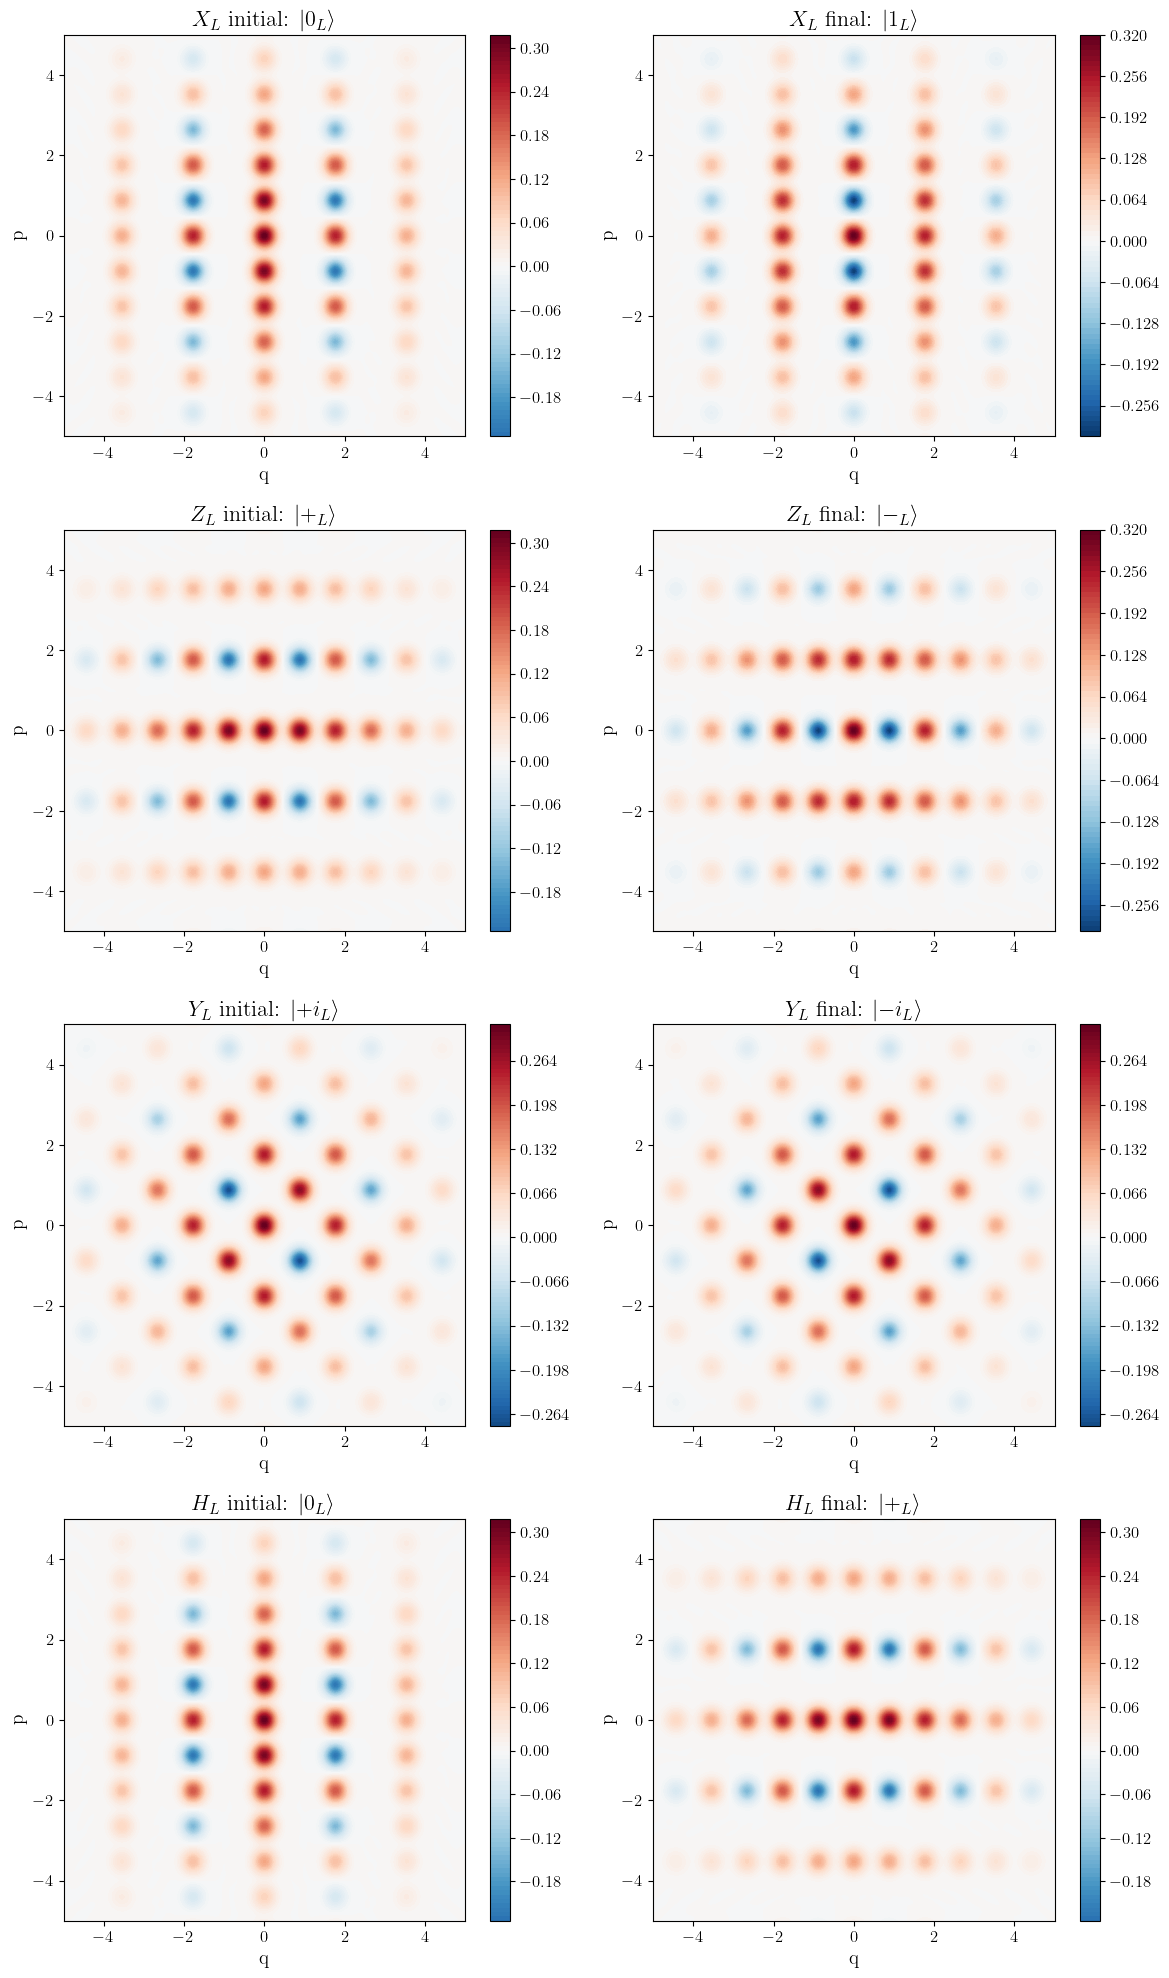

In [5]:
fig, axes = plt.subplots(len(gates), 2, figsize=(12, 5 * len(gates)))

for row, (gate_name, (init_label, final_label)) in zip(axes, gates.items()):
    _, result = trajectories[gate_name]
    plot_wigner(
        result.states[0],
        x_bound=x_bound,
        y_bound=y_bound,
        ax=row[0],
        title=rf"${gate_name}$ initial: $\ket{{{init_label}}}$",
    )
    plot_wigner(
        result.states[-1],
        x_bound=x_bound,
        y_bound=y_bound,
        ax=row[1],
        title=rf"${gate_name}$ final: $\ket{{{final_label}}}$",
    )

fig.tight_layout()
fig.savefig("../../figs/brachistochrone/brachistochrone_gate_initial_and_final_wigners.pdf", bbox_inches="tight")
plt.show()

## Photon-number distribution along a trajectory

For one representative gate, track the Fock populations $P(n, t) = \bra{n} \rho(t) \ket{n}$ over the pulse duration. The Fock-space truncation boundary should remain unpopulated throughout; the left- and right-edge distributions should match the Fock profiles of the initial and final cardinal states.


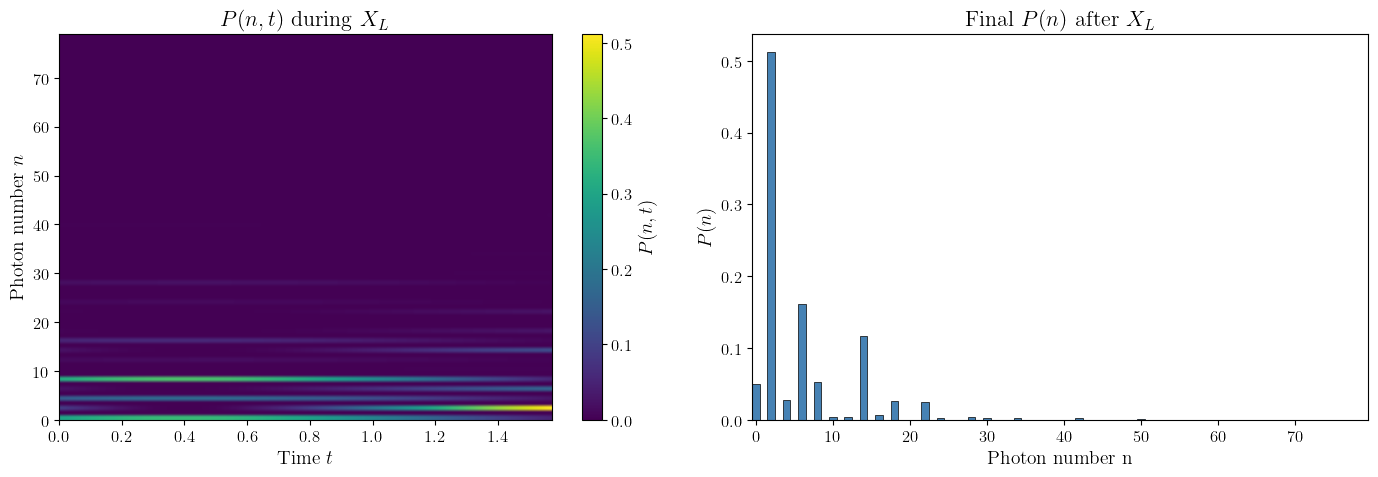

In [6]:
focus_gate = "X_L"
tlist, result = trajectories[focus_gate]

populations = np.array(
    [np.real(qt.ket2dm(state).diag()) for state in result.states]
)  # shape (n_steps, n_fock)

fig, (ax_heatmap, ax_hist) = plt.subplots(1, 2, figsize=(14, 5))

im = ax_heatmap.imshow(
    populations.T,
    extent=(tlist[0], tlist[-1], 0, n_fock - 1),
    aspect="auto",
    origin="lower",
    cmap="viridis",
)
fig.colorbar(im, ax=ax_heatmap, label=r"$P(n, t)$")
ax_heatmap.set_xlabel(r"Time $t$")
ax_heatmap.set_ylabel(r"Photon number $n$")
ax_heatmap.set_title(rf"$P(n, t)$ during ${focus_gate}$")

plot_photon_number(
    result.states[-1],
    ax=ax_hist,
    title=rf"Final $P(n)$ after ${focus_gate}$",
)

fig.tight_layout()
fig.savefig(
    f"../../figs/brachistochrone/brachistochrone_gate_{focus_gate}_photon_distribution.pdf",
    bbox_inches="tight",
)
plt.show()

## Structure of the optimal Hamiltonian

The brachistochrone construction produces $H$ of rank two in the $\{\ket{\psi_i}, \ket{\psi_f^\perp}\}$ subspace. In the Fock basis this is a sparse, Hermitian matrix whose nonzero structure reflects the coherent-state content of both the initial and final GKP states. Real and imaginary parts are shown on a shared symmetric diverging scale.


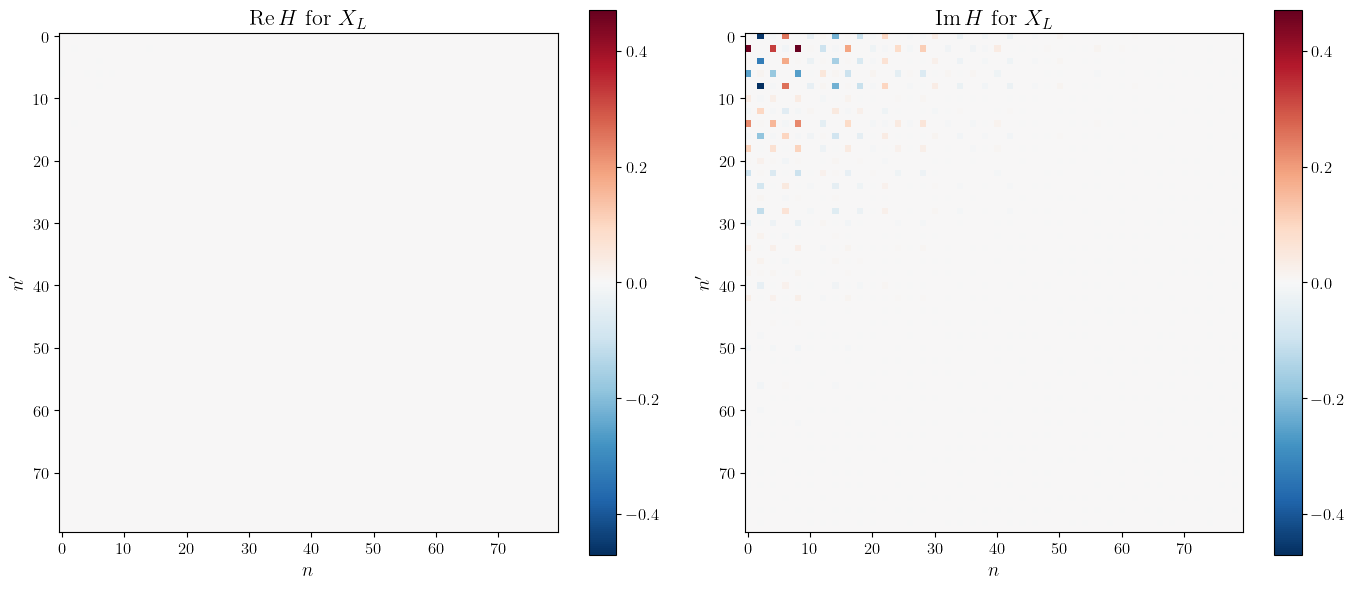

In [7]:
focus_gate = "X_L"
h = optimal_hamiltonians[focus_gate].full()

vmax = float(np.max(np.abs(h)))
fig, (ax_re, ax_im) = plt.subplots(1, 2, figsize=(14, 6))

im_re = ax_re.imshow(h.real, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax_re.set_title(rf"$\mathrm{{Re}}\, H$ for ${focus_gate}$")
ax_re.set_xlabel(r"$n$")
ax_re.set_ylabel(r"$n'$")
fig.colorbar(im_re, ax=ax_re)

im_im = ax_im.imshow(h.imag, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax_im.set_title(rf"$\mathrm{{Im}}\, H$ for ${focus_gate}$")
ax_im.set_xlabel(r"$n$")
ax_im.set_ylabel(r"$n'$")
fig.colorbar(im_im, ax=ax_im)

fig.tight_layout()
fig.savefig(
    f"../../figs/brachistochrone/brachistochrone_gate_{focus_gate}_hamiltonian.pdf",
    bbox_inches="tight",
)
plt.show()

## Minimum gate times

Summary of $T = \Omega_B / \lVert H \rVert$ for each gate. Orthogonal pairs (e.g., $\ket{0_L}$ and $\ket{1_L}$ for $X_L$) have $\Omega_B = \pi/2$, saturating the bound for unit $\lVert H \rVert$. Non-orthogonal pairs (e.g., $\ket{0_L}$ and $\ket{+_L}$ for $H_L$) have smaller Bures angle and therefore shorter minimum time.


In [8]:
for gate_name, t in min_times.items():
    init_label, final_label = gates[gate_name]
    print(f"  {gate_name} (|{init_label}> -> |{final_label}>): T = {t:.4f}")

  X_L (|0_L> -> |1_L>): T = 1.5707
  Z_L (|+_L> -> |-_L>): T = 1.5708
  Y_L (|+i_L> -> |-i_L>): T = 1.5707
  H_L (|0_L> -> |+_L>): T = 0.7854
